# BitCrusher Buck Regulator Calculations
<!-- <div> -->
<!-- 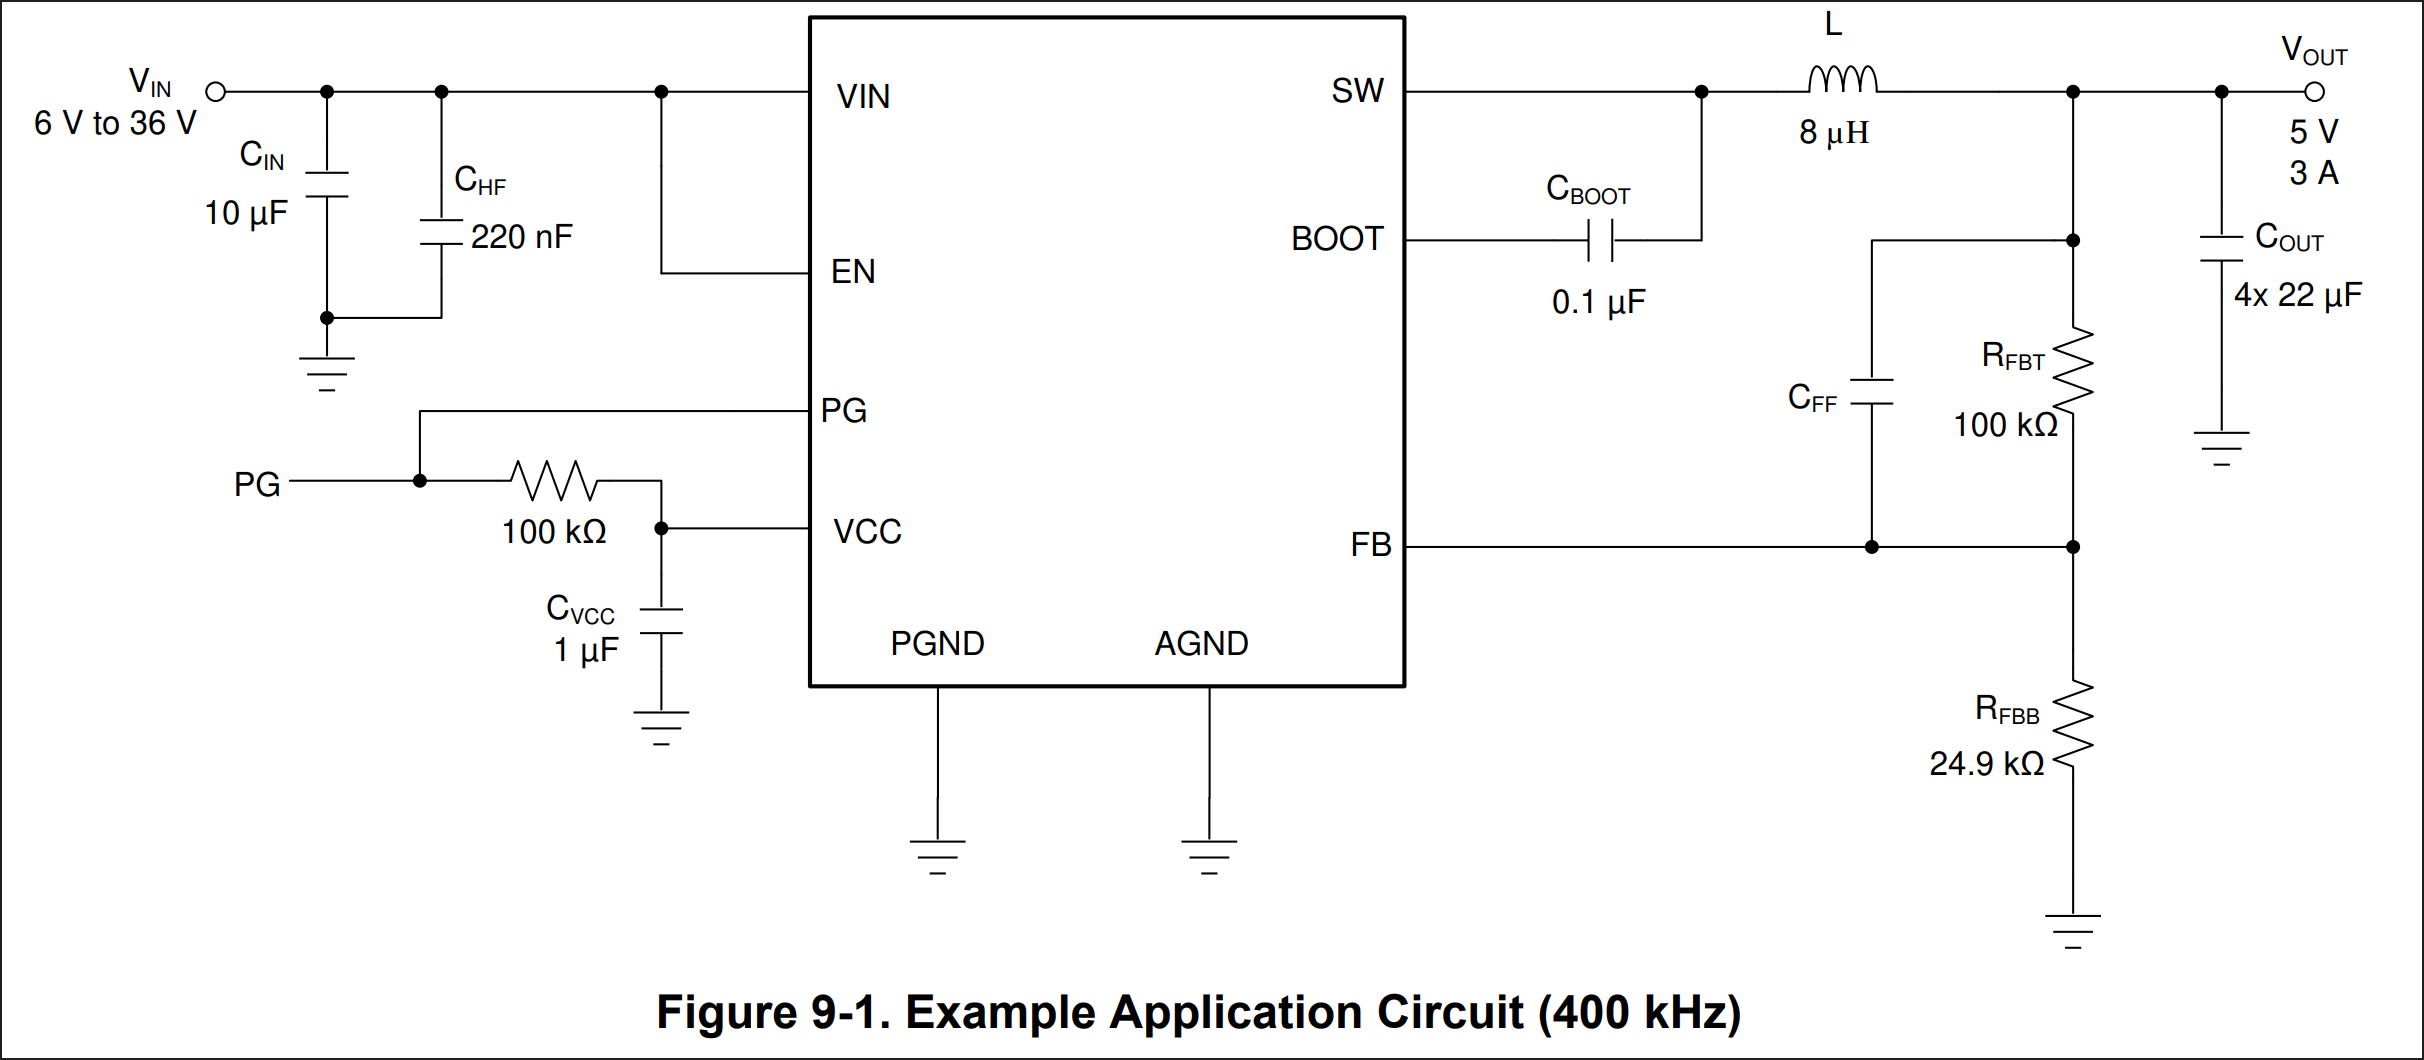  -->
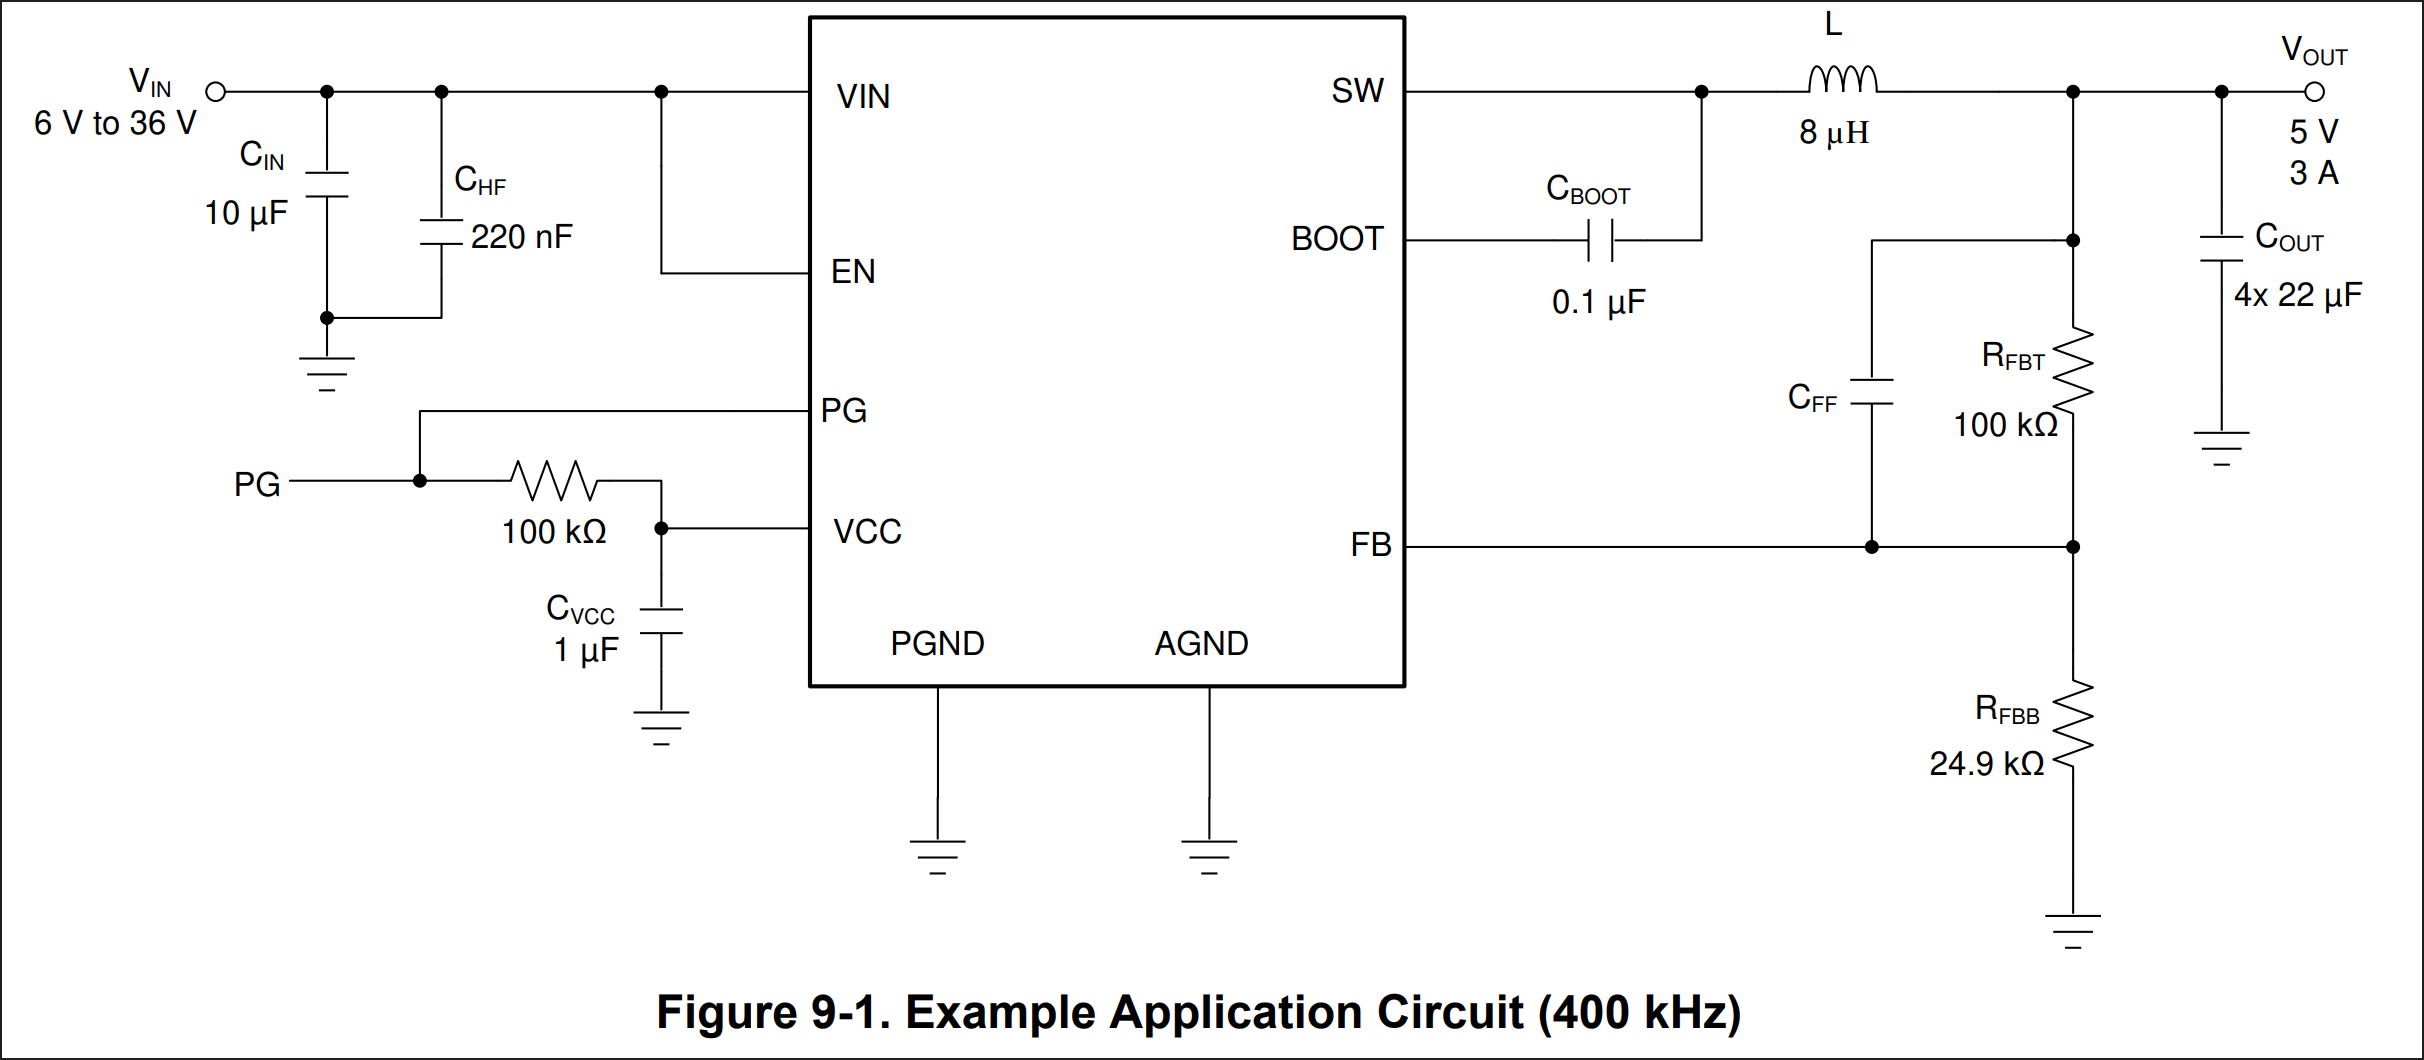
<!-- </div> -->

In [1]:
from sympy import symbols, nsolve, solve, Eq

# Defining circuit values
Vin, Vout = symbols('Vin Vout')
Cff, Cout = symbols('Cff Cout')
Cout_ESR = symbols('Cout_ESR')
Rfbt, Rfbb = symbols('Rfbt Rfbb')
f_sw = symbols('f_sw')
Lout = symbols('Lout')

# Assigning recomended defaults
Rfbt = 100000
f_sw = 400000
Iout_max = 3
design_K = 0.3  # inductor current ripple (as fraction of Iout_max)

In [3]:
# Calculate Rfbb for required Vout
Vref = 1  # ideally
Rfbb = Rfbt / ((Vout / Vref) - 1)

In [4]:
# Calculate inductance
Lout = ((Vin - Vout)/(f_sw * design_K * Iout_max)) * (Vout / Vin)

In [8]:
design_Vout = 6
design_Vin = 22
print(f"Rfbb: {Rfbb.subs(Vout, design_Vout).evalf()} Ohms")
print(f"Lout: {Lout.subs([(Vout, design_Vout), (Vin, design_Vin)]).evalf():.2e} H")
lmin = 0.28*(design_Vout/f_sw)

if Lout.subs([(Vout, design_Vout), (Vin, design_Vin)]).evalf() <= lmin:
    print(f"Induction too low! {Lout.subs([(Vout, design_Vout), (Vin, design_Vin)]).evalf():.2e} <= {lmin:.2e}")

Rfbb: 20000.0000000000 Ohms
Lout: 1.21e-5 H


In [9]:
# Find minimum output capacitance and maximum output capacitor ESR
D = design_Vout / design_Vin

# Accepted change in voltage (Vout_trans) for the given change in current (Iout_trans)
Vout_trans = 0.25
Iout_trans = 2.2

Cout_constraints = []
ESR_constraints = []

Cout_min = (Iout_trans / (f_sw * Vout_trans * design_K)) * ((1-D)*(1+design_K) + ((design_K**2)/12) * (2-D))
Cout_max = 1000e-6
print(f"Cout >= {Cout_min:.2e} C (should be <= {Cout_max:.2e} C)")
Cout_constraints.append(Cout >= Cout_min)
Cout_constraints.append(Cout <= Cout_max)

ESR_max = ((2+design_K) * Vout_trans) / (2*Iout_trans*(1 + design_K + ((design_K**2)/12) * (1 + 1/(1-D))))
print(f"ESR <= {ESR_max:.2e} Ohms")
ESR_constraints.append(Cout_ESR <= ESR_max)

print("Cout ESR Constraints:\t", solve(ESR_constraints, Cout_ESR))
print("Cout Constraints:\t", solve(Cout_constraints, Cout))


Cout >= 7.03e-05 C (should be <= 1.00e-03 C)
ESR <= 9.92e-02 Ohms
Cout ESR Constraints:	 (-oo < Cout_ESR) & (Cout_ESR <= 0.0991657145320887)
Cout Constraints:	 (7.02833333333334e-5 <= Cout) & (Cout <= 0.001)


In [10]:
# Determine peak to peak voltage ripple
Cout_tmp = Cout_min  # higher C_out reduces voltage ripple
ESR_tmp = ESR_max  # lower Cout_ESR reduces voltage ripple

Vr = Iout_trans * ((ESR_tmp**2) + (1/((8*f_sw*Cout_tmp)**2)))**(0.5)
print(f"Peak to peak voltage ripple: {Vr:.4f} V")

Peak to peak voltage ripple: 0.2184 V
